# House Price Prediction

## 1. Get the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

## 2. Exploratory Data Analysis (EDA)

### Understand the data

In [7]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
train.shape

(1460, 81)

In [9]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [10]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Missing Values

In [11]:
missing_values = train.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

### Numerical Features

In [12]:
numerical_features = train.select_dtypes(include=["number"])

numerical_features.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


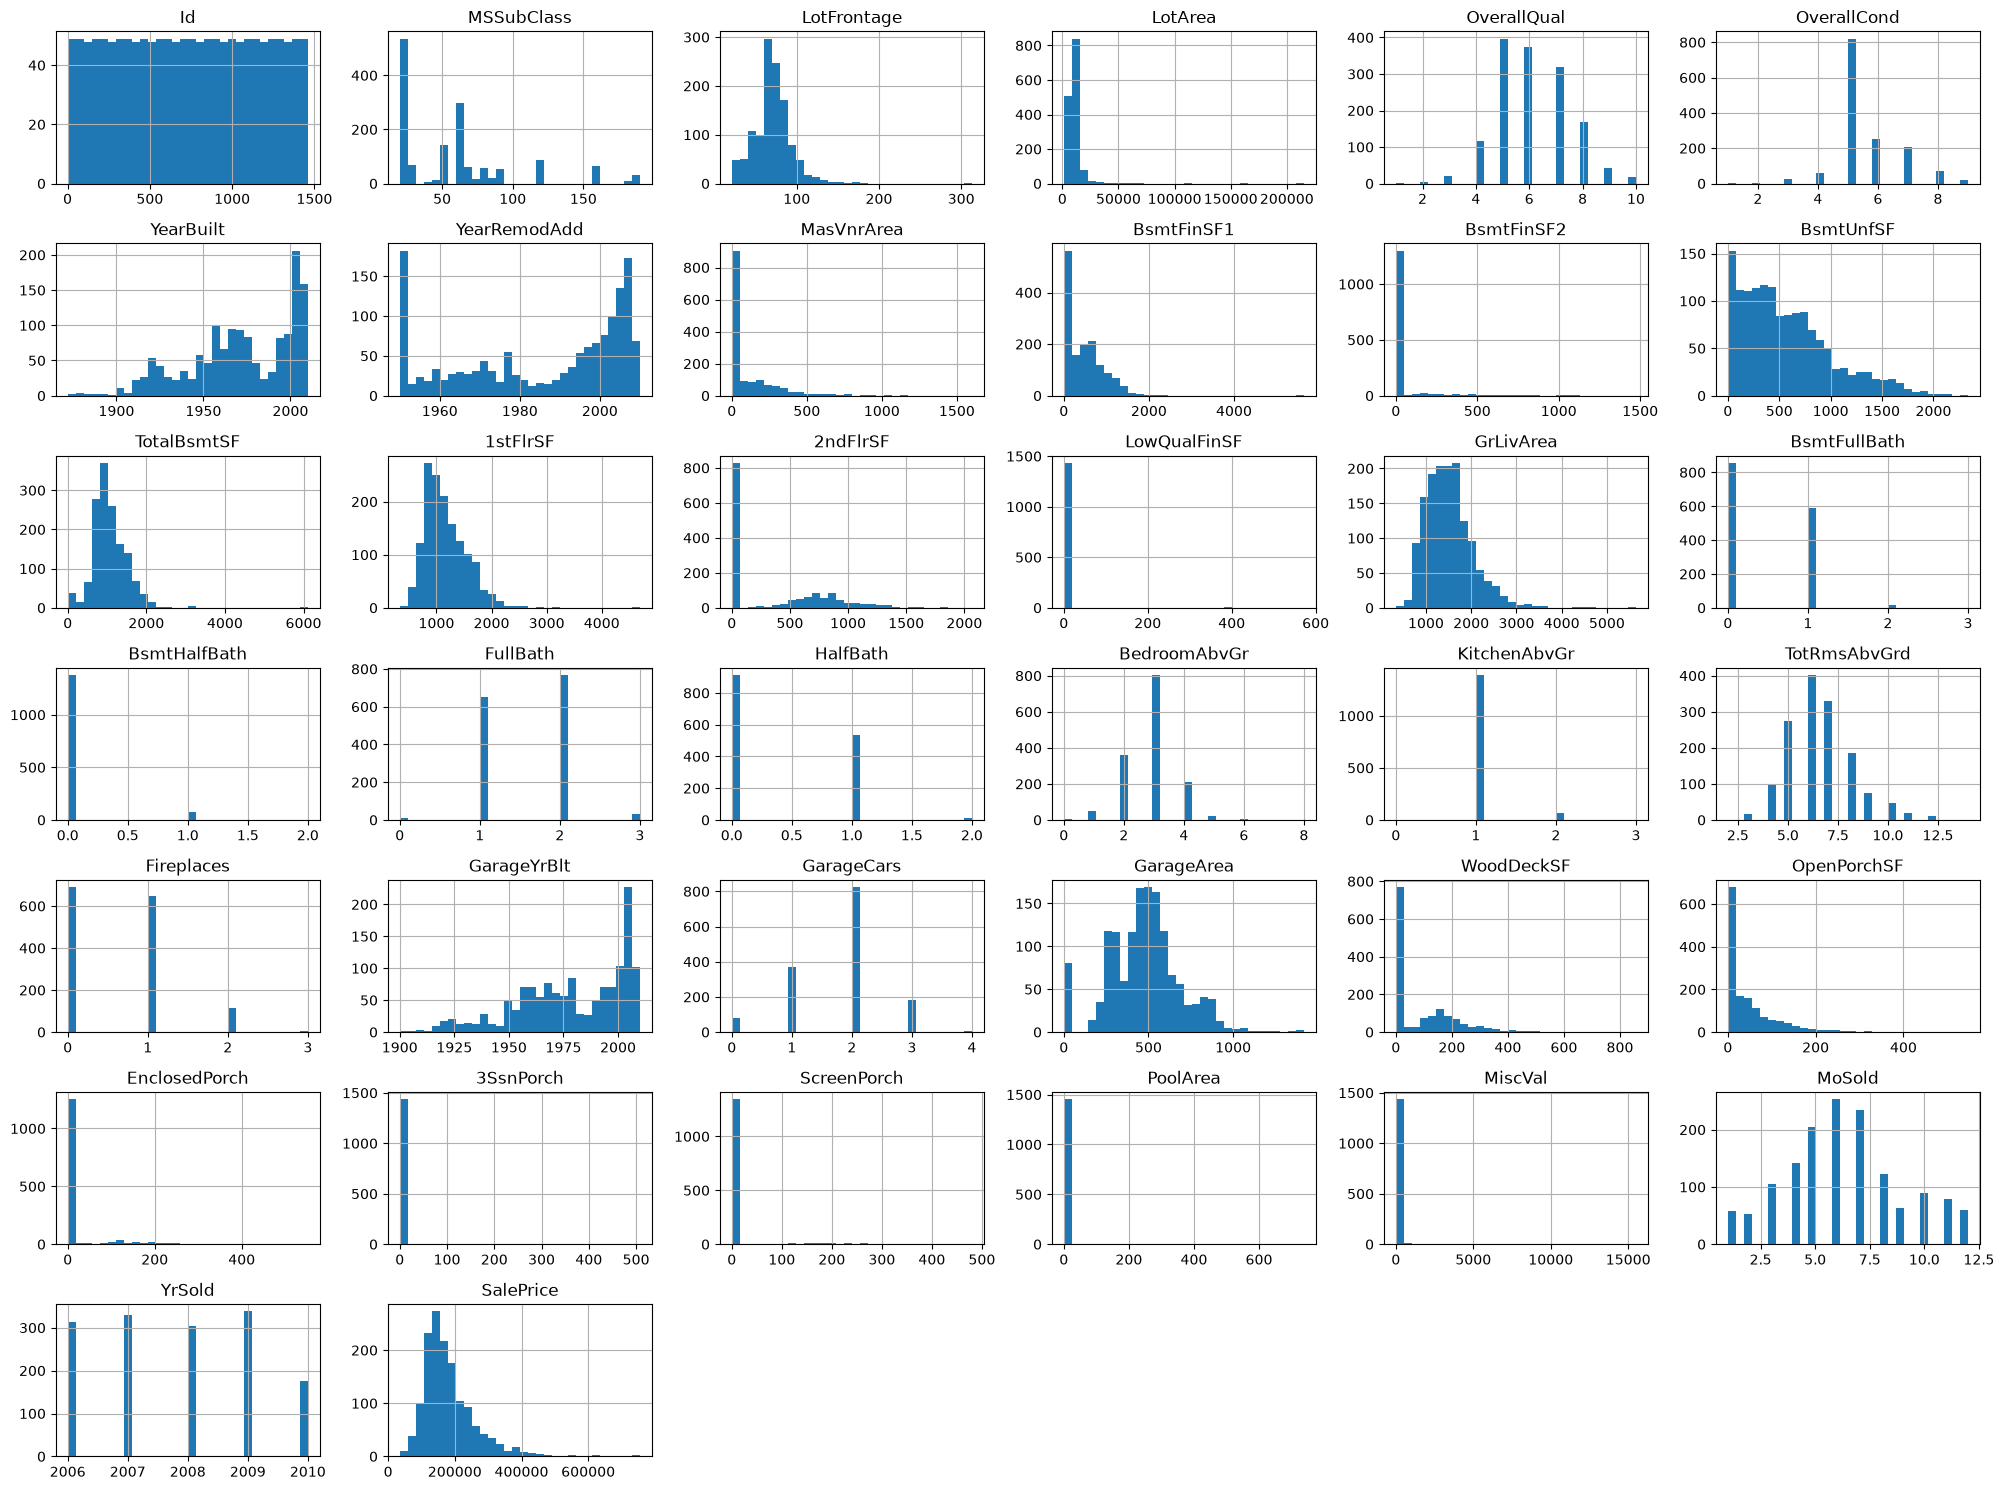

In [13]:
numerical_features.hist(figsize=(20, 15), bins=30)

plt.tight_layout()
plt.show()

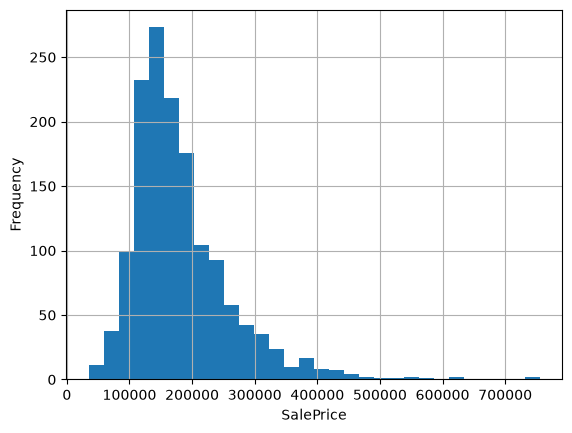

In [14]:
train["SalePrice"].hist(bins=30)

plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

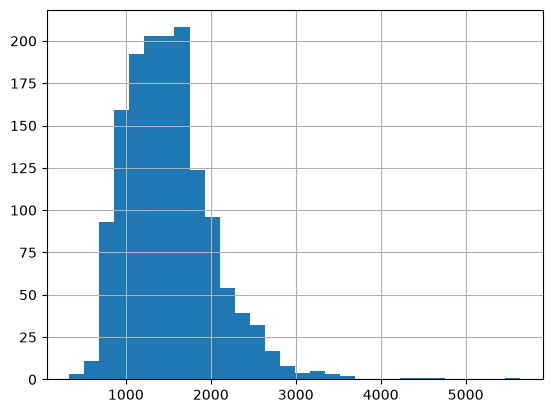

In [15]:
train["GrLivArea"].hist(bins=30)
plt.show()

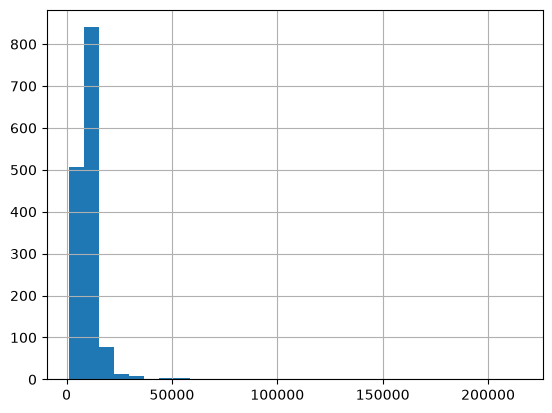

In [16]:
train["LotArea"].hist(bins=30)
plt.show()

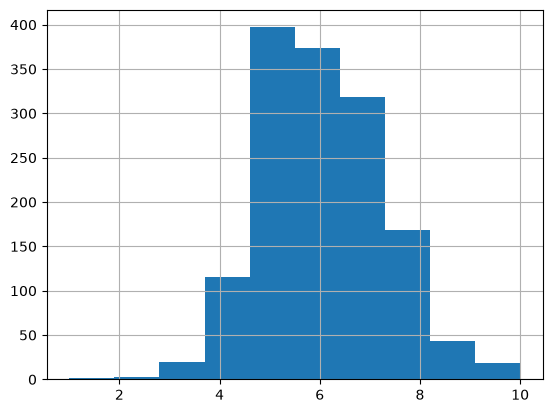

In [17]:
train["OverallQual"].hist(bins=10)
plt.show()

In [18]:
train["SalePrice"].sort_values(ascending=False).head()

691     755000
1182    745000
1169    625000
898     611657
803     582933
Name: SalePrice, dtype: int64

In [19]:
train["GrLivArea"].sort_values(ascending=False).head()

1298    5642
523     4676
1182    4476
691     4316
1169    3627
Name: GrLivArea, dtype: int64

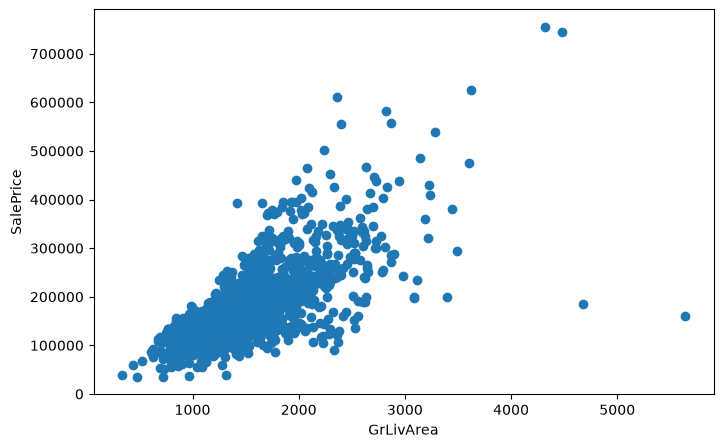

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(train["GrLivArea"], train["SalePrice"])

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

plt.show()

### Categorical Features

In [21]:
categorical_features = train.select_dtypes(include=["str"])

categorical_features.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [22]:
train["Neighborhood"].unique()

<StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

In [23]:
train["Neighborhood"].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [24]:
train["Neighborhood"].value_counts()[train["Neighborhood"].value_counts() < 5]

Neighborhood
Blueste    2
Name: count, dtype: int64

In [25]:
train["HouseStyle"].value_counts()

HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

In [26]:
train["GarageType"].value_counts()

GarageType
Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

In [27]:
train["MSZoning"].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

In [28]:
train["KitchenQual"].value_counts()

KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

### Correlation

In [29]:
correlation_matrix = train.select_dtypes(include="number").corr()

correlation_matrix

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


In [30]:
correlation_matrix["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

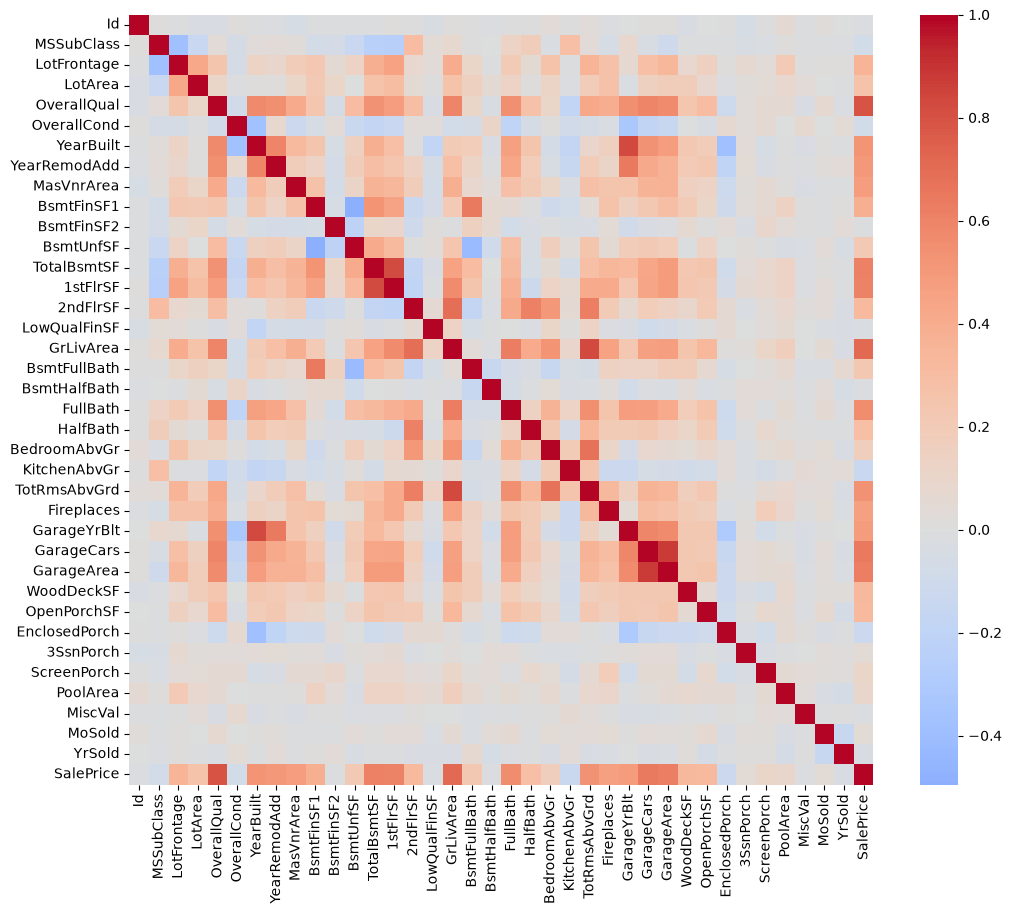

In [31]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.show()

### Observations
The exploratory data analysis provided a solid understanding of the dataset before preprocessing and model development. Several features contained missing values, with many of these likely representing the absence of a feature rather than missing information. The numerical features revealed that SalePrice is positively skewed, and a few potential outliers were identified, particularly houses with unusually large living areas but relatively low sale prices.

The categorical features contained a mix of nominal and ordinal variables with varying category frequencies. Some categories were highly represented, while others appeared only a few times. Several categorical features also contained missing values that may require special handling during preprocessing.

Correlation analysis showed that OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and YearBuilt have the strongest positive relationships with SalePrice. In addition, several features were highly correlated with each other, indicating potential multicollinearity. Overall, the dataset appears well suited for regression modeling, with a number of informative features and clear opportunities for preprocessing and feature engineering before training machine learning models.

# 3. Feature Engineering

Feature engineering is performed after the exploratory data analysis to create more informative features from the original dataset.

The following techniques are applied:

- Create new numerical features.
- Create age-related features.
- Create binary indicator features.
- Create total bathroom count.
- Apply log transformation to highly skewed numerical variables.
- Remove extreme outliers.
- Apply a log transformation to the target variable.

The engineered dataset will later be used for preprocessing and model training.

In [32]:
# Total living area
train["TotalSF"] = (
    train["TotalBsmtSF"]
    + train["1stFlrSF"]
    + train["2ndFlrSF"]
)

test["TotalSF"] = (
    test["TotalBsmtSF"]
    + test["1stFlrSF"]
    + test["2ndFlrSF"]
)

# House age
train["HouseAge"] = train["YrSold"] - train["YearBuilt"]
test["HouseAge"] = test["YrSold"] - test["YearBuilt"]

# Remodel age
train["RemodelAge"] = train["YrSold"] - train["YearRemodAdd"]
test["RemodelAge"] = test["YrSold"] - test["YearRemodAdd"]

# Total bathrooms
train["TotalBathrooms"] = (
    train["FullBath"]
    + 0.5 * train["HalfBath"]
    + train["BsmtFullBath"]
    + 0.5 * train["BsmtHalfBath"]
)

test["TotalBathrooms"] = (
    test["FullBath"]
    + 0.5 * test["HalfBath"]
    + test["BsmtFullBath"]
    + 0.5 * test["BsmtHalfBath"]
)

# Binary indicator features
binary_features = {
    "HasGarage": "GarageArea",
    "HasBasement": "TotalBsmtSF",
    "HasFireplace": "Fireplaces",
    "HasPool": "PoolArea",
    "HasSecondFloor": "2ndFlrSF",
}

for new_feature, feature in binary_features.items():
    train[new_feature] = (train[feature] > 0).astype(int)
    test[new_feature] = (test[feature] > 0).astype(int)

# Log-transform skewed features
log_features = [
    "GrLivArea",
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF"
]

for feature in log_features:
    train[feature] = np.log1p(train[feature])
    test[feature] = np.log1p(test[feature])

# Log-transform target
train["SalePrice"] = np.log1p(train["SalePrice"])

# Remove extreme outliers
outlier_mask = ~(
    (train["GrLivArea"] > np.log1p(4000))
    & (train["SalePrice"] < np.log1p(300000))
)

train = train.loc[outlier_mask].copy()

### Observation

Several new features were created based on domain knowledge. Age-related features, total living area, total bathrooms and binary indicators may provide additional predictive information.

Highly skewed numerical variables together with the target variable were log-transformed to reduce skewness and improve the assumptions of linear models.

Extreme outliers were removed to reduce their influence during training.

## 4. Data Preprocessing Pipeline

In [33]:
# Separate features and target
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

# Split into training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Handle Missing Values

Missing values will be handled inside the preprocessing pipeline. Numerical features are imputed using the median, while categorical features are imputed using the most frequent category.

### Encode Categorical Features

Categorical features are encoded using two different encoding techniques based on the nature of the data. Features with a natural ordering, such as quality and condition ratings, are encoded using `OrdinalEncoder` to preserve their inherent ranking. Features without any meaningful order, such as neighborhoods and zoning categories, are encoded using `OneHotEncoder` to prevent the model from learning artificial ordinal relationships. This approach ensures that each categorical feature is represented in the most appropriate way before model training.

In [34]:
ordinal_features = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC",

    "BsmtExposure",

    "BsmtFinType1",
    "BsmtFinType2",

    "Functional",

    "GarageFinish",

    "Fence",

    "LotShape",

    "LandSlope",

    "PavedDrive",

    "Utilities"
]

In [35]:
ordinal_categories = [

    ["Po","Fa","TA","Gd","Ex"],      
    ["Po","Fa","TA","Gd","Ex"],      

    ["None","Po","Fa","TA","Gd","Ex"],   
    ["None","Po","Fa","TA","Gd","Ex"],   

    ["Po","Fa","TA","Gd","Ex"],      

    ["Po","Fa","TA","Gd","Ex"],      

    ["None","Po","Fa","TA","Gd","Ex"],   

    ["None","Po","Fa","TA","Gd","Ex"],   
    ["None","Po","Fa","TA","Gd","Ex"],   

    ["None","Fa","TA","Gd","Ex"],        

    ["None","No","Mn","Av","Gd"],        

    ["None","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],  
    ["None","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],  

    ["Sal","Sev","Maj2","Maj1","Mod","Min2","Min1","Typ"],

    ["None","Unf","RFn","Fin"],

    ["None","MnWw","GdWo","MnPrv","GdPrv"],

    ["IR3","IR2","IR1","Reg"],

    ["Sev","Mod","Gtl"],

    ["N","P","Y"],

    ["ELO","NoSeWa","NoSewr","AllPub"]
]

In [36]:
numerical_features = X_train.select_dtypes(include="number").columns

In [37]:
nominal_features = [
    column
    for column in X_train.select_dtypes(include="str").columns
    if column not in ordinal_features
]

### Scale Numerical Features

Numerical features will be standardized using StandardScaler inside the preprocessing pipeline.

### Build Preprocessing Pipeline

The preprocessing pipeline combines all preprocessing steps into a single workflow. Numerical features are imputed using the median and standardized with `StandardScaler`. Ordinal categorical features are imputed and encoded using `OrdinalEncoder` to preserve their natural ordering, while nominal categorical features are encoded using `OneHotEncoder` to avoid introducing artificial ordinal relationships. A `ColumnTransformer` applies the appropriate preprocessing pipeline to each feature group, ensuring that all transformations are performed consistently and without data leakage.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [39]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [40]:
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    (
        "encoder",
        OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

In [41]:
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [42]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("ord", ordinal_pipeline, ordinal_features),
    ("nom", nominal_pipeline, nominal_features)
])

In [43]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_valid_prepared = preprocessor.transform(X_valid)

In [44]:
# Convert to DataFrame for easier inspection

feature_names = preprocessor.get_feature_names_out()

X_train_prepared = pd.DataFrame(
    X_train_prepared,
    columns=feature_names,
    index=X_train.index
)

X_valid_prepared = pd.DataFrame(
    X_valid_prepared,
    columns=feature_names,
    index=X_valid.index
)

In [45]:
X_train_prepared.head()

,num__Id,num__MSSubClass,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__YearBuilt,num__YearRemodAdd,num__MasVnrArea,num__BsmtFinSF1,...,nom__SaleType_ConLw,nom__SaleType_New,nom__SaleType_Oth,nom__SaleType_WD,nom__SaleCondition_Abnorml,nom__SaleCondition_AdjLand,nom__SaleCondition_Alloca,nom__SaleCondition_Family,nom__SaleCondition_Normal,nom__SaleCondition_Partial
254,-1.117761,-0.857409,0.017096,-0.159702,-0.781412,0.372581,-0.459933,-1.346989,-0.580392,1.103191,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1066,0.810767,0.078786,-0.503746,-0.295247,-0.053675,1.268311,0.731291,0.447637,-0.580392,-1.027807,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
865,0.333385,-0.857409,-0.030253,-0.079944,-0.781412,0.372581,-0.029769,-0.716444,-0.137330,0.885931,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
799,0.176632,-0.155263,-0.456397,-0.460879,-0.781412,1.268311,-1.121725,-1.686513,0.888710,0.287310,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
380,-0.818507,-0.155263,-0.929890,-1.173284,-0.781412,0.372581,-1.551889,-1.686513,-0.580392,-0.523948,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 5. Train the Baseline Model
The first model is a Linear Regression model. It serves as a baseline that later models can be compared against. The model is trained using the preprocessed training data and evaluated on the validation set using Root Mean Squared Error (RMSE).

In [46]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()

In [47]:
linear_regression.fit(X_train_prepared, y_train)

y_pred = linear_regression.predict(X_valid_prepared)

In [48]:
from sklearn.metrics import root_mean_squared_error, r2_score

# Training predictions
linear_train_pred = linear_regression.predict(X_train_prepared)

linear_train_rmse = root_mean_squared_error(y_train, linear_train_pred)
linear_train_r2 = r2_score(y_train, linear_train_pred)

print(f"Train RMSE: {linear_train_rmse:.3f}")
print(f"Train R²: {linear_train_r2:.3f}")

# Validation predictions
linear_valid_pred = linear_regression.predict(X_valid_prepared)

linear_valid_rmse = root_mean_squared_error(y_valid, linear_valid_pred)
linear_valid_r2 = r2_score(y_valid, linear_valid_pred)

print(f"Validation RMSE: {linear_valid_rmse:.3f}")
print(f"Validation R²: {linear_valid_r2:.3f}")

Train RMSE: 0.089
Train R²: 0.950
Validation RMSE: 0.128
Validation R²: 0.903


### Observation

The baseline Linear Regression model achieved a training RMSE of **0.089** and a validation RMSE of **0.128**, with corresponding R² scores of **0.950** and **0.903**. The relatively small performance gap between the training and validation sets suggests that the model generalizes well and does not exhibit significant overfitting. Overall, the baseline model explains approximately **90%** of the variance in the log-transformed house prices and provides a strong benchmark for evaluating more advanced regression models.

## 6. Better Models
The baseline Linear Regression model provided a strong starting point for predicting house prices. In this section, several more advanced regression models are evaluated and compared. Each model is trained using the same preprocessed training data and evaluated on the validation set using Root Mean Squared Error (RMSE) and the coefficient of determination (R²).

Using multiple algorithms allows us to determine whether more complex models can improve predictive performance while maintaining good generalization.

### Ridge Regression

Ridge Regression extends Linear Regression by introducing L2 regularization, which penalizes large coefficients. This helps reduce overfitting and improves generalization when features are correlated.

In [49]:
from sklearn.linear_model import Ridge

ridge = Ridge(random_state=42)

ridge.fit(X_train_prepared, y_train)

ridge_train_pred = ridge.predict(X_train_prepared)

ridge_train_rmse = root_mean_squared_error(y_train, ridge_train_pred)
ridge_train_r2 = r2_score(y_train, ridge_train_pred)

print(f"Train RMSE: {ridge_train_rmse:.3f}")
print(f"Train R²: {ridge_train_r2:.3f}")

ridge_valid_pred = ridge.predict(X_valid_prepared)

ridge_valid_rmse = root_mean_squared_error(y_valid, ridge_valid_pred)
ridge_valid_r2 = r2_score(y_valid, ridge_valid_pred)

print(f"Validation RMSE: {ridge_valid_rmse:.3f}")
print(f"Validation R²: {ridge_valid_r2:.3f}")

Train RMSE: 0.090
Train R²: 0.948
Validation RMSE: 0.115
Validation R²: 0.921


### Lasso Regression

Lasso Regression extends Linear Regression by introducing L1 regularization, which encourages sparse models by shrinking some coefficients exactly to zero. This allows the model to perform automatic feature selection while helping reduce overfitting.

In [50]:
from sklearn.linear_model import Lasso

lasso = Lasso(
    alpha=0.0005,
    random_state=42,
    max_iter=10000
)

lasso.fit(X_train_prepared, y_train)

lasso_train_pred = lasso.predict(X_train_prepared)

lasso_train_rmse = root_mean_squared_error(y_train, lasso_train_pred)
lasso_train_r2 = r2_score(y_train, lasso_train_pred)

print(f"Train RMSE: {lasso_train_rmse:.3f}")
print(f"Train R²: {lasso_train_r2:.3f}")

lasso_valid_pred = lasso.predict(X_valid_prepared)

lasso_valid_rmse = root_mean_squared_error(y_valid, lasso_valid_pred)
lasso_valid_r2 = r2_score(y_valid, lasso_valid_pred)

print(f"Validation RMSE: {lasso_valid_rmse:.3f}")
print(f"Validation R²: {lasso_valid_r2:.3f}")

Train RMSE: 0.097
Train R²: 0.940
Validation RMSE: 0.108
Validation R²: 0.930


### Elastic Net

Elastic Net combines both L1 (Lasso) and L2 (Ridge) regularization. It can perform feature selection while also reducing the instability that Lasso may suffer from when highly correlated features are present. This often makes Elastic Net a strong general-purpose linear regression model.

In [51]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(
    alpha=0.0005,
    l1_ratio=0.5,
    random_state=42,
    max_iter=10000
)

elastic_net.fit(X_train_prepared, y_train)

elastic_net_train_pred = elastic_net.predict(X_train_prepared)

elastic_net_train_rmse = root_mean_squared_error(y_train, elastic_net_train_pred)
elastic_net_train_r2 = r2_score(y_train, elastic_net_train_pred)

print(f"Train RMSE: {elastic_net_train_rmse:.3f}")
print(f"Train R²: {elastic_net_train_r2:.3f}")

elastic_net_valid_pred = elastic_net.predict(X_valid_prepared)

elastic_net_valid_rmse = root_mean_squared_error(y_valid, elastic_net_valid_pred)
elastic_net_valid_r2 = r2_score(y_valid, elastic_net_valid_pred)

print(f"Validation RMSE: {elastic_net_valid_rmse:.3f}")
print(f"Validation R²: {elastic_net_valid_r2:.3f}")

Train RMSE: 0.094
Train R²: 0.943
Validation RMSE: 0.110
Validation R²: 0.928


### Random Forest Regression

Random Forest Regression is an ensemble learning method that combines many decision trees into a single model. Each tree is trained on a random subset of the training data and features, reducing variance and improving generalization. Random Forest can model complex non-linear relationships and is generally much more powerful than ordinary linear regression models.

In [52]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_prepared, y_train)

random_forest_train_pred = random_forest.predict(X_train_prepared)

random_forest_train_rmse = root_mean_squared_error(y_train, random_forest_train_pred)
random_forest_train_r2 = r2_score(y_train, random_forest_train_pred)

print(f"Train RMSE: {random_forest_train_rmse:.3f}")
print(f"Train R²: {random_forest_train_r2:.3f}")

random_forest_valid_pred = random_forest.predict(X_valid_prepared)

random_forest_valid_rmse = root_mean_squared_error(y_valid, random_forest_valid_pred)
random_forest_valid_r2 = r2_score(y_valid, random_forest_valid_pred)

print(f"Validation RMSE: {random_forest_valid_rmse:.3f}")
print(f"Validation R²: {random_forest_valid_r2:.3f}")

Train RMSE: 0.049
Train R²: 0.985
Validation RMSE: 0.144
Validation R²: 0.877


### Gradient Boosting Regression

Gradient Boosting Regression is an ensemble learning method that builds a sequence of decision trees, where each new tree attempts to correct the errors made by the previous ones. By combining many weak learners into a strong predictive model, Gradient Boosting is capable of capturing complex non-linear relationships and often achieves excellent performance on structured tabular datasets.

In [53]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(X_train_prepared, y_train)

gradient_boosting_train_pred = gradient_boosting.predict(X_train_prepared)

gradient_boosting_train_rmse = root_mean_squared_error(y_train, gradient_boosting_train_pred)
gradient_boosting_train_r2 = r2_score(y_train, gradient_boosting_train_pred)

print(f"Train RMSE: {gradient_boosting_train_rmse:.3f}")
print(f"Train R²: {gradient_boosting_train_r2:.3f}")

gradient_boosting_valid_pred = gradient_boosting.predict(X_valid_prepared)

gradient_boosting_valid_rmse = root_mean_squared_error(y_valid, gradient_boosting_valid_pred)
gradient_boosting_valid_r2 = r2_score(y_valid, gradient_boosting_valid_pred)

print(f"Validation RMSE: {gradient_boosting_valid_rmse:.3f}")
print(f"Validation R²: {gradient_boosting_valid_r2:.3f}")

Train RMSE: 0.052
Train R²: 0.983
Validation RMSE: 0.119
Validation R²: 0.916


### XGBoost Regression

XGBoost (Extreme Gradient Boosting) is an optimized implementation of gradient boosting designed for speed, scalability, and predictive performance. It builds decision trees sequentially, where each new tree corrects the errors made by the previous ones. XGBoost includes built-in regularization techniques that help reduce overfitting and is widely regarded as one of the strongest algorithms for structured tabular datasets.

In [54]:
from xgboost import XGBRegressor

xgb_regressor = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_regressor.fit(X_train_prepared, y_train)

xgb_train_pred = xgb_regressor.predict(X_train_prepared)

xgb_train_rmse = root_mean_squared_error(y_train, xgb_train_pred)
xgb_train_r2 = r2_score(y_train, xgb_train_pred)

print(f"Train RMSE: {xgb_train_rmse:.3f}")
print(f"Train R²: {xgb_train_r2:.3f}")

xgb_valid_pred = xgb_regressor.predict(X_valid_prepared)

xgb_valid_rmse = root_mean_squared_error(y_valid, xgb_valid_pred)
xgb_valid_r2 = r2_score(y_valid, xgb_valid_pred)

print(f"Validation RMSE: {xgb_valid_rmse:.3f}")
print(f"Validation R²: {xgb_valid_r2:.3f}")

Train RMSE: 0.053
Train R²: 0.982
Validation RMSE: 0.114
Validation R²: 0.923


### LightGBM Regression

LightGBM (Light Gradient Boosting Machine) is a gradient boosting framework developed by Microsoft. Unlike traditional boosting algorithms, it grows trees leaf-wise instead of level-wise, allowing it to achieve higher accuracy while remaining extremely fast and memory efficient. LightGBM is widely used for structured tabular datasets and is one of the most competitive algorithms in machine learning competitions.

In [55]:
from lightgbm import LGBMRegressor

lightgbm = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lightgbm.fit(X_train_prepared, y_train)

lightgbm_train_pred = lightgbm.predict(X_train_prepared)

lightgbm_train_rmse = root_mean_squared_error(y_train, lightgbm_train_pred)
lightgbm_train_r2 = r2_score(y_train, lightgbm_train_pred)

print(f"Train RMSE: {lightgbm_train_rmse:.3f}")
print(f"Train R²: {lightgbm_train_r2:.3f}")

lightgbm_valid_pred = lightgbm.predict(X_valid_prepared)

lightgbm_valid_rmse = root_mean_squared_error(y_valid, lightgbm_valid_pred)
lightgbm_valid_r2 = r2_score(y_valid, lightgbm_valid_pred)

print(f"Validation RMSE: {lightgbm_valid_rmse:.3f}")
print(f"Validation R²: {lightgbm_valid_r2:.3f}")

Train RMSE: 0.013
Train R²: 0.999
Validation RMSE: 0.131
Validation R²: 0.899


### CatBoost Regression

CatBoost (Categorical Boosting) is a gradient boosting algorithm developed by Yandex. It is designed to handle categorical features efficiently while reducing prediction bias through ordered boosting. Although categorical variables have already been encoded in this project, CatBoost remains a powerful ensemble method and often achieves state-of-the-art performance on structured tabular datasets.

In [56]:
from catboost import CatBoostRegressor

catboost = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

catboost.fit(X_train_prepared, y_train)

catboost_train_pred = catboost.predict(X_train_prepared)

catboost_train_rmse = root_mean_squared_error(y_train, catboost_train_pred)
catboost_train_r2 = r2_score(y_train, catboost_train_pred)

print(f"Train RMSE: {catboost_train_rmse:.3f}")
print(f"Train R²: {catboost_train_r2:.3f}")

catboost_valid_pred = catboost.predict(X_valid_prepared)

catboost_valid_rmse = root_mean_squared_error(y_valid, catboost_valid_pred)
catboost_valid_r2 = r2_score(y_valid, catboost_valid_pred)

print(f"Validation RMSE: {catboost_valid_rmse:.3f}")
print(f"Validation R²: {catboost_valid_r2:.3f}")

Train RMSE: 0.051
Train R²: 0.983
Validation RMSE: 0.114
Validation R²: 0.923


### Model Comparison

The following section compares all trained regression models using the same validation dataset. The models are evaluated using Root Mean Squared Error (RMSE) and the coefficient of determination (R²). Lower RMSE and higher R² indicate better predictive performance.

In [57]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Train RMSE": [
        linear_train_rmse,
        ridge_train_rmse,
        lasso_train_rmse,
        elastic_net_train_rmse,
        random_forest_train_rmse,
        gradient_boosting_train_rmse,
        xgb_train_rmse,
        lightgbm_train_rmse,
        catboost_train_rmse
    ],

    "Validation RMSE": [
        linear_valid_rmse,
        ridge_valid_rmse,
        lasso_valid_rmse,
        elastic_net_valid_rmse,
        random_forest_valid_rmse,
        gradient_boosting_valid_rmse,
        xgb_valid_rmse,
        lightgbm_valid_rmse,
        catboost_valid_rmse
    ],

    "Train R²": [
        linear_train_r2,
        ridge_train_r2,
        lasso_train_r2,
        elastic_net_train_r2,
        random_forest_train_r2,
        gradient_boosting_train_r2,
        xgb_train_r2,
        lightgbm_train_r2,
        catboost_train_r2
    ],

    "Validation R²": [
        linear_valid_r2,
        ridge_valid_r2,
        lasso_valid_r2,
        elastic_net_valid_r2,
        random_forest_valid_r2,
        gradient_boosting_valid_r2,
        xgb_valid_r2,
        lightgbm_valid_r2,
        catboost_valid_r2
    ]
})

results

,Model,Train RMSE,Validation RMSE,Train R²,Validation R²
0,Linear Regression,0.089159,0.127644,0.949504,0.903349
1,Ridge Regression,0.090391,0.115247,0.948099,0.921211
2,Lasso Regression,0.096921,0.108363,0.940330,0.930343
3,Elastic Net,0.094358,0.110047,0.943443,0.928161
4,Random Forest,0.048881,0.143937,0.984823,0.877101
5,Gradient Boosting,0.052183,0.119069,0.982702,0.915899
6,XGBoost,0.052927,0.113808,0.982206,0.923167
7,LightGBM,0.012826,0.130782,0.998955,0.898540
8,CatBoost,0.051376,0.114043,0.983233,0.922849


In [58]:
results.sort_values(
    by="Validation RMSE",
    ascending=True
).reset_index(drop=True)

,Model,Train RMSE,Validation RMSE,Train R²,Validation R²
0,Lasso Regression,0.096921,0.108363,0.940330,0.930343
1,Elastic Net,0.094358,0.110047,0.943443,0.928161
2,XGBoost,0.052927,0.113808,0.982206,0.923167
3,CatBoost,0.051376,0.114043,0.983233,0.922849
4,Ridge Regression,0.090391,0.115247,0.948099,0.921211
5,Gradient Boosting,0.052183,0.119069,0.982702,0.915899
6,Linear Regression,0.089159,0.127644,0.949504,0.903349
7,LightGBM,0.012826,0.130782,0.998955,0.898540
8,Random Forest,0.048881,0.143937,0.984823,0.877101


### Observation
The comparison shows that Lasso Regression achieved the best overall validation performance, with the lowest Validation RMSE (0.108) and the highest Validation R² (0.930). Elastic Net, XGBoost, and CatBoost also performed well and produced very similar results, indicating that they generalize effectively to unseen data. In contrast, Random Forest and LightGBM achieved extremely low training errors but noticeably worse validation performance, suggesting a higher degree of overfitting. Overall, the results indicate that the feature engineering and preprocessing pipeline was highly effective, as even the baseline Linear Regression model performed well. Based on the validation results, Lasso Regression is currently the strongest candidate for further evaluation using cross-validation.

## 7. Cross Validation
Cross-validation provides a more reliable estimate of a model's performance than evaluating it on a single validation split. Instead of relying on one train-validation partition, the training data is divided into multiple folds, allowing the model to be trained and evaluated several times on different subsets of the data. This reduces the risk that the evaluation depends on a fortunate or unfortunate split of the dataset and provides a better estimate of how well the model is expected to generalize to unseen data.

Since Lasso Regression, Elastic Net, XGBoost, and CatBoost achieved the strongest validation performance in the previous phase, these models will be evaluated using 5-fold cross-validation. The models will be compared using Root Mean Squared Error (RMSE), where a lower score indicates better predictive performance.

### Lasso Regression

In [59]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation
lasso_cv_scores = cross_val_score(
    lasso,
    X_train_prepared,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Convert to positive RMSE
lasso_cv_rmse = -lasso_cv_scores

# Variables for model comparison
lasso_cv_mean_rmse = lasso_cv_rmse.mean()
lasso_cv_std_rmse = lasso_cv_rmse.std()

print("Fold RMSE:", np.round(lasso_cv_rmse, 4))
print(f"Mean RMSE: {lasso_cv_mean_rmse:.4f}")
print(f"Standard Deviation: {lasso_cv_std_rmse:.4f}")

Fold RMSE: [0.1085 0.1231 0.1266 0.1021 0.1026]
Mean RMSE: 0.1126
Standard Deviation: 0.0103


### Elastic Net

In [60]:
elastic_net_cv_scores = cross_val_score(
    elastic_net,
    X_train_prepared,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

elastic_net_cv_rmse = -elastic_net_cv_scores

elastic_net_cv_mean_rmse = elastic_net_cv_rmse.mean()
elastic_net_cv_std_rmse = elastic_net_cv_rmse.std()

print("Fold RMSE:", np.round(elastic_net_cv_rmse, 4))
print(f"Mean RMSE: {elastic_net_cv_mean_rmse:.4f}")
print(f"Standard Deviation: {elastic_net_cv_std_rmse:.4f}")

Fold RMSE: [0.1124 0.121  0.1258 0.1036 0.1052]
Mean RMSE: 0.1136
Standard Deviation: 0.0087


### XGBoost

In [61]:
xgb_cv_scores = cross_val_score(
    xgb_regressor,
    X_train_prepared,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

xgb_cv_rmse = -xgb_cv_scores

xgb_cv_mean_rmse = xgb_cv_rmse.mean()
xgb_cv_std_rmse = xgb_cv_rmse.std()

print("Fold RMSE:", np.round(xgb_cv_rmse, 4))
print(f"Mean RMSE: {xgb_cv_mean_rmse:.4f}")
print(f"Standard Deviation: {xgb_cv_std_rmse:.4f}")

Fold RMSE: [0.1109 0.1222 0.1253 0.1216 0.1065]
Mean RMSE: 0.1173
Standard Deviation: 0.0073


### CatBoost

In [62]:
catboost_cv_scores = cross_val_score(
    catboost,
    X_train_prepared,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

catboost_cv_rmse = -catboost_cv_scores

catboost_cv_mean_rmse = catboost_cv_rmse.mean()
catboost_cv_std_rmse = catboost_cv_rmse.std()

print("Fold RMSE:", np.round(catboost_cv_rmse, 4))
print(f"Mean RMSE: {catboost_cv_mean_rmse:.4f}")
print(f"Standard Deviation: {catboost_cv_std_rmse:.4f}")

Fold RMSE: [0.1099 0.1225 0.1293 0.1235 0.1031]
Mean RMSE: 0.1177
Standard Deviation: 0.0097


### Model Comparison
The following table summarizes the cross-validation performance of the top-performing regression models. Each model was evaluated using **5-fold cross-validation**, where the **mean RMSE** represents the expected prediction error on unseen data and the **standard deviation** measures the consistency of the model across different folds.

The model with the lowest mean RMSE and the smallest standard deviation is considered the strongest candidate for the final hyperparameter tuning stage.

In [63]:
cv_results = pd.DataFrame({
    "Model": [
        "Lasso Regression",
        "Elastic Net",
        "XGBoost",
        "CatBoost"
    ],

    "Mean RMSE": [
        lasso_cv_mean_rmse,
        elastic_net_cv_mean_rmse,
        xgb_cv_mean_rmse,
        catboost_cv_mean_rmse
    ],

    "Standard Deviation": [
        lasso_cv_std_rmse,
        elastic_net_cv_std_rmse,
        xgb_cv_std_rmse,
        catboost_cv_std_rmse
    ]
})

cv_results

,Model,Mean RMSE,Standard Deviation
0,Lasso Regression,0.112571,0.010339
1,Elastic Net,0.113609,0.008675
2,XGBoost,0.117287,0.007268
3,CatBoost,0.117651,0.009661


In [64]:
cv_results = cv_results.sort_values(
    by="Mean RMSE",
    ascending=True
).reset_index(drop=True)

cv_results

,Model,Mean RMSE,Standard Deviation
0,Lasso Regression,0.112571,0.010339
1,Elastic Net,0.113609,0.008675
2,XGBoost,0.117287,0.007268
3,CatBoost,0.117651,0.009661


### Observation

Cross-validation was performed on the four best-performing models from the previous evaluation to obtain a more reliable estimate of their generalization performance. The results show that Lasso Regression achieved the lowest mean RMSE (0.1126), making it the strongest performer across the validation folds. Elastic Net followed closely with a mean RMSE of 0.1136, while XGBoost (0.1173) and CatBoost (0.1177) produced slightly higher errors.

The standard deviations were relatively low for all models, indicating stable performance across the folds and suggesting that none of the models were highly sensitive to the specific train-validation split. Since the differences between the models are relatively small, cross-validation confirms that all four are competitive candidates.

Based on these results, the next step is to perform hyperparameter tuning on all four models to determine whether their predictive performance can be further improved before selecting the final model.

## 8. Hyperparameter Tuning & Train Final Model

### Lasso Tuning

In [65]:
from sklearn.model_selection import RandomizedSearchCV

lasso_params = {
    "alpha": np.logspace(-4, 1, 100)
}

lasso_search = RandomizedSearchCV(
    Lasso(max_iter=10000),
    lasso_params,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)
lasso_search.fit(X_train_prepared, y_train)
print("Best alpha:", lasso_search.best_params_)
print("Best CV RMSE:", -lasso_search.best_score_)

Best alpha: {'alpha': np.float64(0.0005722367659350221)}
Best CV RMSE: 0.11252227709743008


### ElasticNet tuning

In [66]:
elasticnet_params = {
    "alpha": np.logspace(-4, 1, 50),
    "l1_ratio": np.linspace(0.1, 0.9, 20)
}

elasticnet_search = RandomizedSearchCV(
    ElasticNet(max_iter=10000),
    elasticnet_params,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)
elasticnet_search.fit(X_train_prepared, y_train)
print("Best params:", elasticnet_search.best_params_)
print("Best CV RMSE:", -elasticnet_search.best_score_)

Best params: {'l1_ratio': np.float64(0.5210526315789473), 'alpha': np.float64(0.0010481131341546852)}
Best CV RMSE: 0.11269578240528717


### XGBoost tuning

In [67]:
xgb_params = {
    "n_estimators": [100, 300, 500, 700],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_params,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train_prepared, y_train)
print("Best params:", xgb_search.best_params_)
print("Best CV RMSE:", -xgb_search.best_score_)

Best params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV RMSE: 0.11868973910264077


### CatBoost tuning

In [68]:
catboost_params = {
    "iterations": [300, 500, 700],
    "depth": [4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7]
}

catboost_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    catboost_params,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)
catboost_search.fit(X_train_prepared, y_train)
print("Best params:", catboost_search.best_params_)
print("Best CV RMSE:", -catboost_search.best_score_)

Best params: {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 700, 'depth': 6}
Best CV RMSE: 0.11607370983326844


### Model Comparison
After hyperparameter tuning, the optimized models are compared to determine which one performs best. The comparison is based on the same evaluation metric used previously, ensuring a fair comparison across all models.

The model with the lowest Cross-Validation RMSE will be selected as the final model and trained on the full training dataset before generating predictions on the test set.

In [69]:
tuning_results = pd.DataFrame({
    "Model": ["Lasso", "ElasticNet", "XGBoost", "CatBoost"],
    "Best CV RMSE": [
        -lasso_search.best_score_,
        -elasticnet_search.best_score_,
        -xgb_search.best_score_,
        -catboost_search.best_score_
    ]
}).sort_values("Best CV RMSE").reset_index(drop=True)

tuning_results

,Model,Best CV RMSE
0,Lasso,0.112522
1,ElasticNet,0.112696
2,CatBoost,0.116074
3,XGBoost,0.118690


### Observation

After hyperparameter tuning, Lasso Regression achieved the best Cross-Validation RMSE (0.1125),
followed closely by ElasticNet (0.1127). CatBoost (0.1161) and XGBoost (0.1187) improved
compared to their default-parameter scores but still fall behind the linear models on this dataset.

The strong performance of Lasso and ElasticNet confirms that SalePrice has largely linear
relationships with the engineered features after log-transformation. Tree-based models may
require more extensive feature engineering or larger datasets to fully leverage their capacity.

Based on these results, Lasso, ElasticNet, and CatBoost will be carried forward as candidates
for the final ensemble, as they represent both linear and tree-based approaches that complement
each other well.

### Fine-Tuning Lasso with Grid Search

Based on the RandomizedSearchCV results, we now apply GridSearchCV to perform a more exhaustive
search around the best alpha value found for Lasso Regression.

In [70]:
from sklearn.model_selection import GridSearchCV

best_alpha = lasso_search.best_params_["alpha"]

lasso_grid_params = {
    "alpha": np.logspace(
        np.log10(best_alpha) - 1,
        np.log10(best_alpha) + 1,
        50
    )
}

lasso_grid_search = GridSearchCV(
    Lasso(max_iter=10000),
    lasso_grid_params,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)
lasso_grid_search.fit(X_train_prepared, y_train)

print("Best alpha:", lasso_grid_search.best_params_)
print("Best CV RMSE:", -lasso_grid_search.best_score_)

Best alpha: {'alpha': np.float64(0.0005997688702226969)}
Best CV RMSE: 0.11253081983888844


### Observation

GridSearchCV refined the alpha value to approximately 0.000600, achieving a CV RMSE of 0.11253,
a marginal improvement over the RandomizedSearchCV result (0.11252). The minimal difference
confirms that RandomizedSearchCV had already found a near-optimal alpha, and that Lasso is
well-optimized at this stage.

This will be the final Lasso configuration used in the ensemble.

In [71]:
final_lasso = Lasso(
    alpha=lasso_grid_search.best_params_["alpha"],
    max_iter=10000
)

final_lasso.fit(X_train_prepared, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(0....7688702226969)
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [72]:
final_train_pred = final_lasso.predict(X_train_prepared)

final_train_rmse = root_mean_squared_error(y_train, final_train_pred)
final_train_r2 = r2_score(y_train, final_train_pred)

print(f"Final Train RMSE: {final_train_rmse:.6f}")
print(f"Final Train R²: {final_train_r2:.6f}")

Final Train RMSE: 0.097926
Final Train R²: 0.939086


### Observation
The final Lasso Regression model was successfully retrained using the optimal alpha value found during hyperparameter tuning. This model represents the finalized version of the regression model and will be used for the final evaluation on the unseen test dataset.

## 9. Kaggle Submission
The final Lasso Regression model is now used to generate predictions for the unseen Kaggle test dataset. Since the target variable was log-transformed during training, the predictions are transformed back to the original price scale using the exponential function. Finally, a submission file is created in the format required by Kaggle.

In [73]:
X_test_prepared = preprocessor.transform(test)

X_test_prepared = pd.DataFrame(
    X_test_prepared,
    columns=preprocessor.get_feature_names_out(),
    index=test.index
)

predictions = final_lasso.predict(X_test_prepared)
predictions = np.expm1(predictions)

In [74]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": predictions
})

submission.head()

,Id,SalePrice
0,1461,116060.909449
1,1462,153694.840975
2,1463,179987.458738
3,1464,196808.761610
4,1465,191942.665809


In [75]:
submission.to_csv("../data/submission.csv", index=False)

print("submission.csv has been created successfully.")

submission.csv has been created successfully.
